# Análisis de venta Retail en el entorno CPFR #

Sesiones del Curso revisadas en este 2do módulo

- 🌟 Sesión 01: Introducción a Python.
- 🔁 Sesión 02: Control del flujo, ciclos y condiciones.
- 🛠️ Sesión 03: Estructuras de datos y optimización.
- 🔄 Sesión 04: Programación funcional.
- 🌐 Sesión 05: Apis y bases de datos.
- 📊 Sesión 06: Pandas y análisis exploratorio de datos.
- 🧹 Sesión 07: Funciones vectorizadas, de agregación y limpieza de datos.
- 🔍 Sesión 08: Transformación, filtración y ordenamiento de datos.

Sesiones del Curso revisadas en este 3er módulo
 
- 📏 Sesión 01: Estimados de locación y variabilidad.
- 📈 Sesión 02: Introducción a la visualización de datos: distribuciones.
- 🧩 Sesión 03: Exploración de variables categóricas y análisis multivariable.
- ⚖️ Sesión 04: Correlaciones y regresión lineal simple.
- 📡 Sesión 05: Distribuciones muestrales y técnicas de evaluación de modelos.
- 🎨 Sesión 06: Visualización de datos avanzada.
- 🧪 Sesión 07: Pruebas A/B y procesamiento de lenguaje natural.
- 🤖 Sesión 08: Introducción a machine learning: clasificación no supervisada y supervisada.


# 0.Repaso de base de datos

-Empezamos a generar una conexión con MySQL para revisión de nuestros catalogos:

In [2]:
import mysql.connector
import pandas as pd

# Conexión a tu base de datos local
conexion = mysql.connector.connect(
    host="localhost",
    user="root",              # ← tu usuario de MySQL (normalmente "root")
    password="Televisor.2025#",  # ← la que usas para entrar a Workbench
    database="tecnolochicas_db"
)

# Consulta simple
query = "SELECT * FROM catalogo_sku LIMIT 10"
df_catalogo_sql = pd.read_sql(query, conexion)

print("Conexión exitosa desde MySQL:")
print(df_catalogo_sql.head())

conexion.close()

Conexión exitosa desde MySQL:
  ï»¿Item_number_CCC Cadena_CCC Canal_Venta_CCC Tipo Item_CCC       MARCA_CCC  \
0         3803349CCC        CCC    SUPERMERCADO      BASELINE  CREMAS PREMIUM   
1         3862130CCC        CCC    SUPERMERCADO        IN&OUT      EXHIBICION   
2         3877056CCC        CCC    SUPERMERCADO        IN&OUT         SÃ‰RUMS   
3         3877057CCC        CCC    SUPERMERCADO        IN&OUT         SÃ‰RUMS   
4         3877058CCC        CCC    SUPERMERCADO        IN&OUT         SÃ‰RUMS   

  Priorities_CCC Formato_CCC                      Desc_Cliente_CCC  VNPK_CCC  \
0         TIER 1       TARRO  Crema Corporal Intensa Premium 300 g        10   
1    NO ASIGANDO           0          Exhibidor DÃ­a de las Madres         1   
2           XMAS       TARRO  SÃ©rum Hidratante ClÃ¡sico Caja 72 g        12   
3           XMAS       TARRO        Kit SÃ©rums Surtidos Caja 96 g        12   
4       SEASONAL       TARRO   Kit SÃ©rums EdiciÃ³n Especial 168 g        12   

  

C:\Users\Vale\AppData\Local\Temp\ipykernel_684\1545843859.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_catalogo_sql = pd.read_sql(query, conexion)


## 1. Importación de librerías

Se importan las librerías necesarias para el procesamiento de datos (Pandas, NumPy), 
visualización (Matplotlib, Seaborn) y conexión a base de datos (mysql.connector). 
Esto corresponde a la Sesión 6 (Pandas) y Sesión 5 (APIs y bases de datos) del curso.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

print("Librerías importadas")

Librerías importadas


## 2. Importación y manejo de datos

Se importan los conjuntos de datos desde archivos externos (CSV/Excel), 
correspondientes a la base de ventas y los catálogos de productos. 
Esto aplica lo visto en la Sesión 6: lectura de archivos y estructura de DataFrames.
Adicional se revisa los titulos de las columnas para su uso en en analisis mas adelante.

In [7]:
# Cargar base de ventas
df_ventas = pd.read_excel(r'E:\000-tecnolochicas\Tecnolochicas\SO_SAMPLE.xlsm')

# Cargar catálogos
df_catalogo_tienda = pd.read_csv(r'e:\000-tecnolochicas\Tecnolochicas\Catalogo_Tienda.csv')
df_catalogo_sku = pd.read_csv(r'e:\000-tecnolochicas\Tecnolochicas\Catalogo-SKU.csv')

print(f"Ventas: {df_ventas.shape[0]} filas × {df_ventas.shape[1]} columnas")
print(f"Catálogo Tienda: {df_catalogo_tienda.shape[0]} filas × {df_catalogo_tienda.shape[1]} columnas")
print(f"Catálogo SKU: {df_catalogo_sku.shape[0]} filas × {df_catalogo_sku.shape[1]} columnas")



Ventas: 259035 filas × 13 columnas
Catálogo Tienda: 448 filas × 3 columnas
Catálogo SKU: 88 filas × 13 columnas


## 3. Exploración inicial de los datos

Antes de limpiar o transformar la información, se realiza una exploración 
para entender la estructura, tipos de datos y contenido general. 
Esto corresponde a la Sesión 6 (Análisis Exploratorio de Datos).

In [8]:
print("\nColumnas de ventas:")
print(df_ventas.dtypes)

print("\nPrimeras filas de ventas:")
print(df_ventas.head())

print("\nInformación general:")
print(df_ventas.info())

print("\nEstadísticas descriptivas:")
print(df_ventas.describe())


Columnas de ventas:
Año                   int64
Semana                int64
Año_Semana            int64
NumTienda             int64
Tienda               object
CIUDAD               object
Formato Tienda       object
SKU                   int64
SABOR                object
Marca                object
OH Piezas           float64
Sell Out Importe    float64
Sell Out Piezas     float64
dtype: object

Primeras filas de ventas:
    Año  Semana  Año_Semana  NumTienda                Tienda    CIUDAD  \
0  2024       1      202401          4  XALAPA CRYSTAL 11-82  VERACRUZ   
1  2024       1      202401          4  XALAPA CRYSTAL 11-82  VERACRUZ   
2  2024       1      202401          4  XALAPA CRYSTAL 11-82  VERACRUZ   
3  2024       1      202401          4  XALAPA CRYSTAL 11-82  VERACRUZ   
4  2024       1      202401          4  XALAPA CRYSTAL 11-82  VERACRUZ   

    Formato Tienda       SKU      SABOR               Marca  OH Piezas   \
0  BAJO DESEMBOLSO  68035154  MANDARINA  PICHARD CHOCO

## 4. Limpieza Y transformación de datos

Se identifican y tratan valores nulos, homologación de nombres de las columnas, 
con el fin de preparar los datos para el análisis. 
Esto corresponde a la Sesión 7 (Limpieza de datos).

In [9]:
# Duplicados
duplicados = df_ventas.duplicated().sum()
print(f"Duplicados encontrados: {duplicados}")
df_ventas = df_ventas.drop_duplicates()

# Nulos
nulos = df_ventas.isnull().sum()
print(f"\nValores nulos por columna:\n{nulos[nulos > 0]}")
df_ventas = df_ventas.fillna(0)

print(f"\nDatos limpios: {df_ventas.shape[0]} filas restantes")



Duplicados encontrados: 0

Valores nulos por columna:
OH Piezas             4263
Sell Out Importe    106072
Sell Out Piezas     106081
dtype: int64

Datos limpios: 259035 filas restantes


# 5.Análisis de desempeño: Top SKU por unidades vendidas y su comparación por importe reportado

Se agrupan las ventas por producto y se identifican los 10 con mayor 
cantidad piezas e importe vendida. Esto aplica agregación de datos (Sesión 7) y 
visualización (Sesión 8).

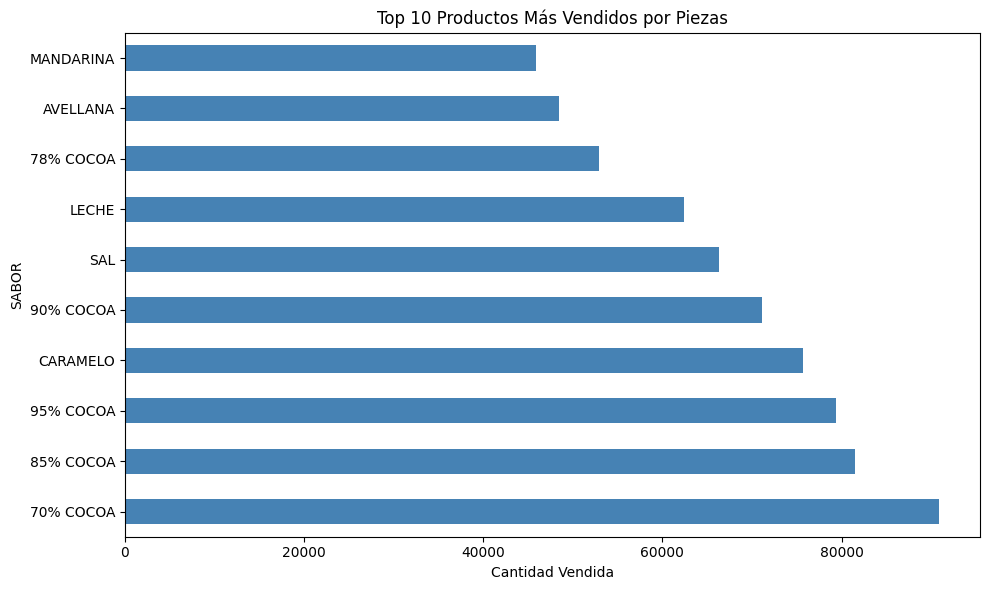

Gráfico generado y guardado como top_10_SKU_Por_Piezas.png


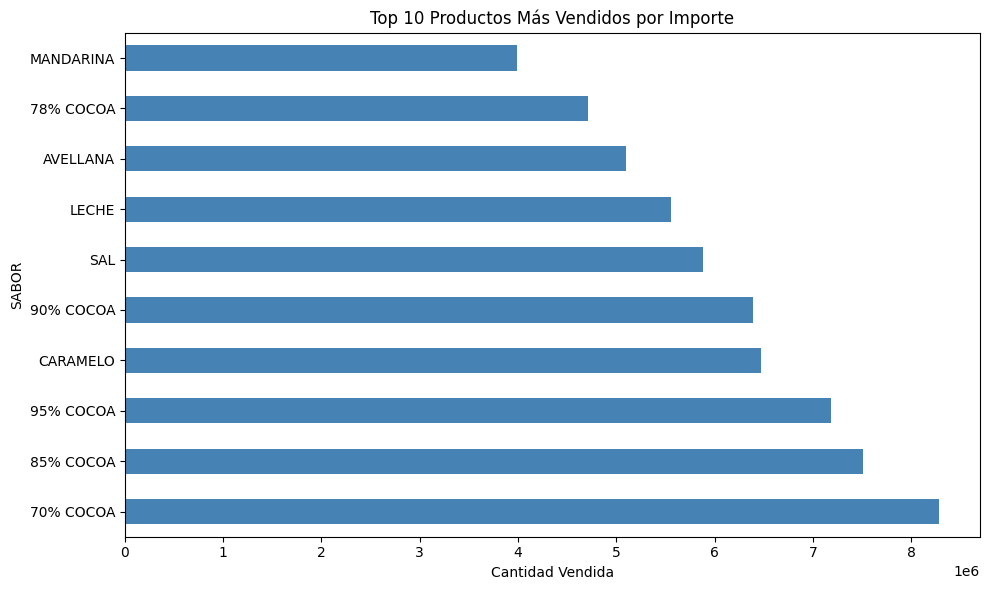

Gráfico generado y guardado como top_10_SKU_Por_Importe.png


In [18]:
top_10_SKU = df_ventas.groupby('SABOR')['Sell Out Piezas'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
top_10_SKU.plot(kind='barh', color='steelblue')
plt.title('Top 10 Productos Más Vendidos por Piezas')
plt.xlabel('Cantidad Vendida')
plt.tight_layout()
plt.savefig('top_10_SKU_Por_Piezas.png')
plt.show()

print("Gráfico generado y guardado como top_10_SKU_Por_Piezas.png")

top_10_Importe = df_ventas.groupby('SABOR')['Sell Out Importe'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
top_10_Importe.plot(kind='barh', color='steelblue')
plt.title('Top 10 Productos Más Vendidos por Importe')
plt.xlabel('Cantidad Vendida')
plt.tight_layout()
plt.savefig('top_10_SKU_Por_Importe.png')
plt.show()

print("Gráfico generado y guardado como top_10_SKU_Por_Importe.png")

Analsis 6.1: Vemos que no hay mucha diferencia entre la clasificación de top ventas, sin embargo, vemos que avellana vende mas en importe que en piezas, comparado con 78% Cocoa, ver si es por diferencia en el punto de precio o 78% entro en liquidación y por eso vende mas en pz que importe.

In [19]:
print("\nEstadísticas descriptivas:")
print(df_ventas.describe())


Estadísticas descriptivas:
                Año         Semana     Año_Semana      NumTienda  \
count  259035.00000  259035.000000  259035.000000  259035.000000   
mean     2024.82207      24.433945  202506.640983     311.414940   
std         0.76991      14.471779      74.881106     286.163286   
min      2024.00000       1.000000  202401.000000       4.000000   
25%      2024.00000      12.000000  202434.000000     101.000000   
50%      2025.00000      24.000000  202513.000000     196.000000   
75%      2025.00000      35.000000  202548.000000     611.000000   
max      2026.00000      52.000000  202633.000000    1444.000000   

                SKU     OH Piezas   Sell Out Importe  Sell Out Piezas  
count  2.590350e+05  259035.000000     259035.000000    259035.000000  
mean   7.440868e+07      22.427680        254.453888         2.796348  
std    5.145566e+06      29.256628        448.573127         5.128095  
min    6.803515e+07    -150.000000       -739.000000       -10.000000  

Analisis 6.2: Vemos que el maximo de inventario en PDV es de 1872 pz, por lo que hay que evaluar si generó un sobreinventario y ver si hubo liquidacion en esa tienda, ya que tambien vemos un pico de venta de 270 piezas vs el promedio de 3pz

# 7. Tendencia semanal de la categoría

Se agrupan las ventas por producto y se identifican los 10 con mayor 
cantidad piezas e importe vendida. Esto aplica agregación de datos (Sesión 7) y 
visualización (Sesión 8).

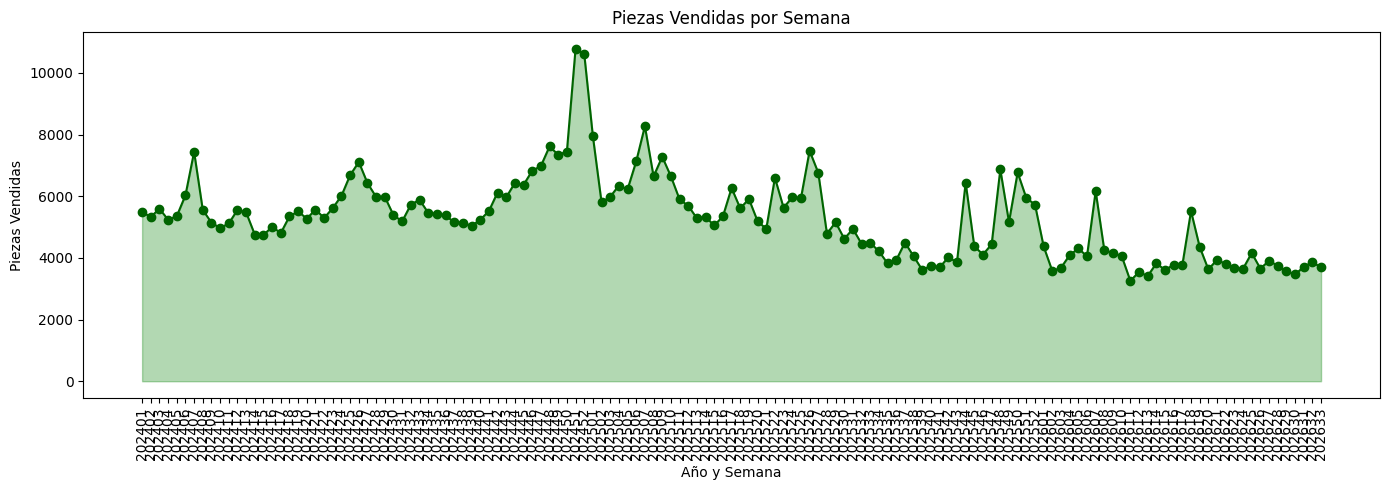

Semana con mayor volumen de venta: 202451 con 10774.0 piezas


In [20]:
ventas_semana = df_ventas.groupby('Año_Semana')['Sell Out Piezas'].sum().sort_index()

plt.figure(figsize=(14, 5))
plt.plot(ventas_semana.index.astype(str), ventas_semana.values, marker='o', color='darkgreen')
plt.fill_between(range(len(ventas_semana)), ventas_semana.values, alpha=0.3, color='green')
plt.title('Piezas Vendidas por Semana')
plt.xlabel('Año y Semana')
plt.ylabel('Piezas Vendidas')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('tendencia_semanal.png')
plt.show()

print("Semana con mayor volumen de venta:", ventas_semana.idxmax(), "con", ventas_semana.max(), "piezas")

Adicional vemos que el pico de 2024 no logra replicarse en 2025, por lo que si vamos a generar un forecast de venta, debemos considerar si si replica el pico pero con tendencia negativa, puede ser caida de venta general en 2025 por subida de precio o por falta de inventario, por lo que evaluaremos ambas cosas.

# 8. Estacionalidad por sabor

Cruzamos sabor contra semana para ver si hay sabores que se disparan solo en ciertas épocas del año, información que sirve para armar la ficha de temporada por variante. Aplica pivot table y visualización (Sesión 8).

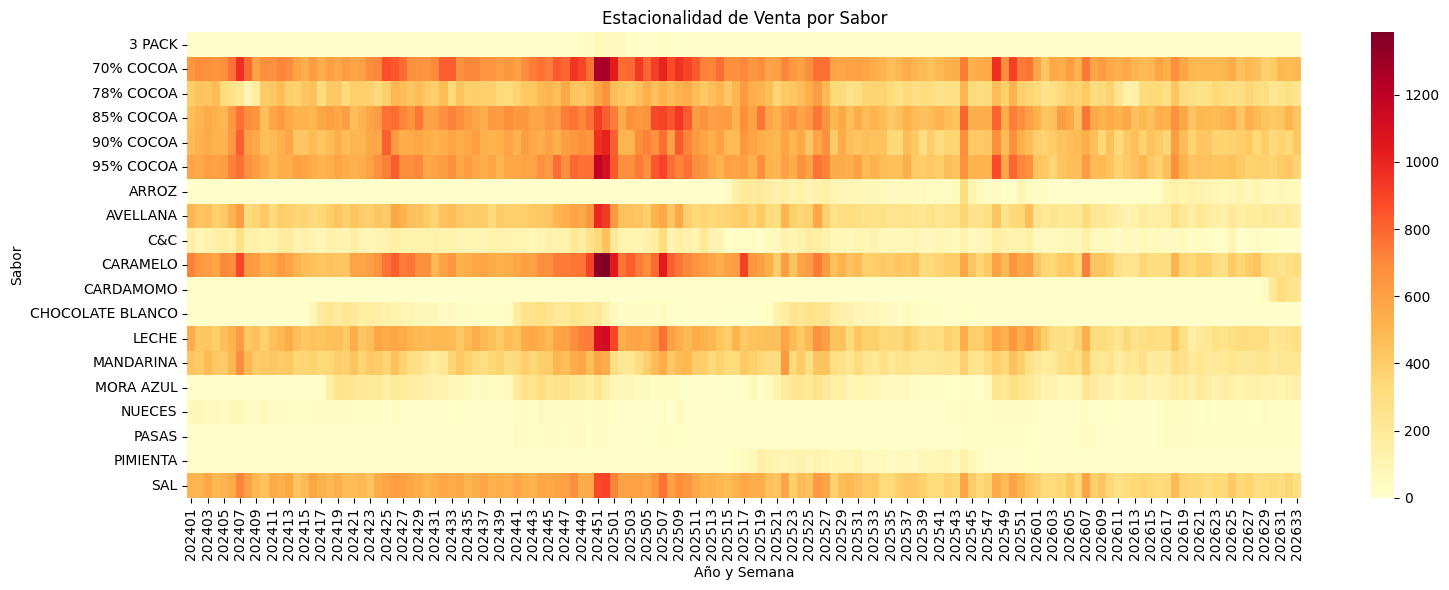

Mapa de calor generado y guardado como heatmap_sabor.png


In [21]:
pivot_sabor = df_ventas.pivot_table(
    values='Sell Out Piezas', index='SABOR', columns='Año_Semana',
    aggfunc='sum', fill_value=0
)

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_sabor, cmap='YlOrRd')
plt.title('Estacionalidad de Venta por Sabor')
plt.xlabel('Año y Semana')
plt.ylabel('Sabor')
plt.tight_layout()
plt.savefig('heatmap_sabor.png')
plt.show()

print("Mapa de calor generado y guardado como heatmap_sabor.png")

A simple vista vemos Sabor Caramelo con mas picos de estacionalidas

# 9. Cálculo del precio unitario

Como no tenemos columna de precio directa, la sacamos dividiendo el importe entre las piezas, solo en las semanas donde sí hubo venta. Con esto armamos un precio de referencia por SKU dentro de nuestro propio portafolio. Aplica funciones vectorizadas (Sesión 7).

In [22]:
df_ventas['precio_unitario'] = np.where(
    df_ventas['Sell Out Piezas'] > 0,
    df_ventas['Sell Out Importe'] / df_ventas['Sell Out Piezas'],
    np.nan
)

precio_promedio_sku = df_ventas.groupby('SKU')['precio_unitario'].mean().round(2).reset_index()
precio_promedio_sku.columns = ['SKU', 'precio_promedio']

print("Precio promedio por SKU:")
print(precio_promedio_sku.sort_values('precio_promedio', ascending=False))

Precio promedio por SKU:
         SKU  precio_promedio
18  84373916           292.87
14  82154490           281.07
16  83673194           268.17
19  84373938           140.08
21  85879574           127.34
20  85017108           108.85
17  84150594            96.94
1   68389486            94.06
10  76379886            94.05
2   68860418            93.91
12  79052952            93.56
3   68860462            93.53
5   73542810            93.12
4   72952880            92.12
11  78756018            91.56
0   68035154            91.18
6   73542920            90.77
7   73542964            90.45
8   75334204            90.34
13  82154468            86.73
9   76374782            79.09
15  82566550            62.87
